# 미국 수입품목 증가율 조회 V1

수출 분석 노트북(`미국_수출품목_증가율_조회_v4.ipynb`, `미국_수출예측지_성장률_long_format_분석.ipynb`)과
동일한 형태로, `us_import_data_downloader_fast.py` + `us_import_sarima_forecast.py` 로 수집/예측된
수입 데이터를 분석합니다.

## 수출 버전과의 스키마 차이

| 구분 | 수출(`us_trade_export_monthly_with_forecast`) | 수입(`us_trade_import_monthly_with_forecast`) |
|---|---|---|
| HS 코드 컬럼 | `hs_code` | `hs_code_6d` |
| 값 컬럼 | `expDlr`(실측) / `expDlr_forecast`(예측) 2개 | `impDlr` 1개 (실측/예측 공용) |
| 실측/예측 구분 | `is_forecast` (0/1) | `forecast_flag` (0/1) |
| 날짜 컬럼 | `date_month_end` | `date` |
| 버전(vintage) 컬럼 | `created_at`/`input_date` 중 자동감지 (동일 hs_code 내 최신 run만 남는 구조로 추정) | `input_date` — **UNIQUE KEY에 포함**되어 매 실행마다 새 행으로 누적 (한국 버전의 `forecast_date`와 동일한 방식) |
| 분기 테이블 | 없음 | `us_trade_import_quarter_with_forecast` 별도 존재 |

수입 쪽은 `input_date`가 명시적으로 버전을 구분하는 키이므로, 수출 버전에서 썼던
`_detect_version_col` + `MAX(created_at)` 추정 로직이 필요 없고 훨씬 명확하게 vintage 비교가 됩니다.

## 구성

1. 핵심 헬퍼 함수 (vintage 조회, 스냅샷 로드, 7개 성장률 지표 계산)
2. ① 사용자 입력
3. ② 데이터 자동 구성
4. ③ 향후 12개월 수입 증가율 랭킹 (전체 HS 코드)
5. ④ 전달 예측 vs 실제 실적 비교
6. ⑤ 전달 예측 vs 이번달 예측 비교 (MoM Diff)
7. ⑥ YoY 수입증가율 변화(가속/둔화) 분석 — 월별/분기별
8. ⑦ 최근 N년 실적+예측 YoY 성장률 가속도 + 기저효과 후보 탐지
9. ⑧ 실적(실선) + 예측(점선) 연속 차트
10. ⑨ HS 코드별 데이터 저장
11. ⑩ 대상 HS 코드 전체 시계열 조회
12. ⑪ 성장률 7종 종합 long-format 테이블 (전체 HS 코드, 과거12m/미래12m/YTD/올해예상/작년/YoY/MoM)


In [14]:

# -*- coding: utf-8 -*-
from __future__ import annotations

import os
import sys
import platform
from pathlib import Path


def _find_project_root(module_name: str = "DATA", max_up: int = 6):
    here = Path.cwd()
    candidates = [here] + list(here.parents)[:max_up]
    for base in candidates:
        if (base / module_name).is_dir():
            return base
    return None


try:
    from DATA.stock_invest_function import *
except ModuleNotFoundError:
    _root = _find_project_root("DATA")
    if _root is None:
        raise ModuleNotFoundError(
            "DATA 패키지를 찾을 수 없습니다. 이 노트북을 프로젝트 루트(DATA 폴더가 있는 위치)에서 "
            "실행하거나, DATA 폴더의 상위 경로를 sys.path에 직접 추가해 주세요."
        )
    sys.path.insert(0, str(_root))
    from DATA.stock_invest_function import *
    print(f"[경로 자동 보정] DATA 모듈을 {_root} 에서 찾아 sys.path에 추가했습니다.")

import numpy as np
import pandas as pd
import matplotlib
import pymysql
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings("ignore")


def _pick_korean_font() -> str:
    system = platform.system()
    candidates = {
        "Windows": ["Malgun Gothic", "NanumGothic"],
        "Darwin":  ["AppleGothic", "NanumGothic"],
        "Linux":   ["NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"],
    }.get(system, ["DejaVu Sans"])
    available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return "DejaVu Sans"


_KOREAN_FONT = _pick_korean_font()
matplotlib.rc('font', family=_KOREAN_FONT)
plt.rcParams['axes.unicode_minus'] = False
print(f"[폰트] 사용 폰트: {_KOREAN_FONT}  (OS: {platform.system()})")

# ============================================================
# DB 연결
# ============================================================
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}


def make_engine(db_info: dict):
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{int(db_info['port'])}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(
        url,
        pool_pre_ping=True,
        pool_recycle=1800,
        connect_args={"connect_timeout": 10, "read_timeout": 60, "write_timeout": 60},
    )


engine = make_engine(db_info)
TABLE_MONTHLY   = "us_trade_import_monthly_with_forecast"
TABLE_QUARTERLY = "us_trade_import_quarter_with_forecast"


[폰트] 사용 폰트: Malgun Gothic  (OS: Windows)


In [15]:

# ============================================================
# 핵심 헬퍼 함수 모음
# ============================================================

def _month_end(ts):
    """DateOffset(months=N) 연산 후 '진짜 월말'로 정규화."""
    return pd.Timestamp(ts) + pd.offsets.MonthEnd(0)


def _sum_window(df_hs, start, end, date_col="date"):
    mask = (df_hs[date_col] >= start) & (df_hs[date_col] <= end)
    sub = df_hs.loc[mask]
    if sub.empty:
        return np.nan, 0
    return sub["impDlr"].sum(), len(sub)


def _growth(base, comp, sanity_ratio=1000.0):
    if pd.isna(base) or pd.isna(comp):
        return np.nan, "missing"
    if base <= 0:
        return np.nan, "base<=0"
    if comp < 0:
        return np.nan, "negative_value"
    g = (comp / base - 1.0) * 100.0
    if comp > base * sanity_ratio:
        return g, "explosive"
    return g, None


def get_available_import_vintages(engine, table=TABLE_MONTHLY):
    """input_date(=vintage/run) 목록 조회. input_date 는 UNIQUE KEY에 포함되어 매 실행마다 누적됨."""
    with engine.connect() as conn:
        rows = conn.execute(text(f"SELECT DISTINCT input_date FROM {table} ORDER BY input_date")).fetchall()
    return [r[0] for r in rows]


def get_vintage_snapshot_import(engine, hs_code, vintage_date, table=TABLE_MONTHLY):
    """특정 HS 코드의 특정 vintage(run) 스냅샷 전체(실측+예측)를 시계열(Series)로 반환."""
    sql = text(f"""
        SELECT date, impDlr, forecast_flag
        FROM {table}
        WHERE hs_code_6d = :hs_code AND input_date = :vintage
        ORDER BY date
    """)
    with engine.connect() as conn:
        rows = conn.execute(sql, {"hs_code": hs_code, "vintage": vintage_date}).fetchall()
    df = pd.DataFrame(rows, columns=["date", "impDlr", "forecast_flag"])
    if df.empty:
        return pd.Series(dtype=float)
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date")["impDlr"].sort_index()


def get_forecast_pivot_for_import_vintage(engine, vintage_date, hs_code=None, table=TABLE_MONTHLY):
    """특정 vintage 의 예측(forecast_flag=1) 구간만 피벗(index=date, columns=hs_code)으로 반환."""
    hs_filter = "AND hs_code_6d = :hs_code" if hs_code else ""
    params = {"vintage": vintage_date}
    if hs_code:
        params["hs_code"] = hs_code
    sql = text(f"""
        SELECT hs_code_6d, date, impDlr
        FROM {table}
        WHERE forecast_flag = 1 AND input_date = :vintage {hs_filter}
        ORDER BY hs_code_6d, date
    """)
    with engine.connect() as conn:
        rows = conn.execute(sql, params).fetchall()
    df = pd.DataFrame(rows, columns=["hs_code_6d", "date", "impDlr"])
    if df.empty:
        return pd.DataFrame()
    df["date"] = pd.to_datetime(df["date"])
    pv = df.pivot_table(index="date", columns="hs_code_6d", values="impDlr", aggfunc="last").sort_index()
    pv.columns = pv.columns.astype(str)
    return pv


def _load_latest_import_data(engine, table=TABLE_MONTHLY):
    """전체 HS 코드의 '최신 vintage(run)' 스냅샷 로드 (랭킹/전체 분석용)."""
    with engine.connect() as conn:
        latest_vintage = conn.execute(text(f"SELECT MAX(input_date) FROM {table}")).scalar()
        if latest_vintage is None:
            raise ValueError(f"{table} 에 데이터가 없습니다.")
        rows = conn.execute(text(f"""
            SELECT hs_code_6d, date, impDlr, forecast_flag
            FROM {table}
            WHERE input_date = :v
            ORDER BY hs_code_6d, date
        """), {"v": latest_vintage}).fetchall()
    df = pd.DataFrame(rows, columns=["hs_code", "date", "impDlr", "forecast_flag"])
    df["date"] = pd.to_datetime(df["date"])
    print(f"[최신 vintage] {latest_vintage} 기준 {len(df):,} 행 / HS {df['hs_code'].nunique():,}개 로드")
    return df, latest_vintage


def analyze_import_growth(engine, base_date, top_n=10, table=TABLE_MONTHLY, sanity_ratio=1000.0):
    """전체 HS 코드에 대해 base_date 기준 과거 12개월 대비 향후 12개월 수입 증가율 랭킹."""
    df_all, _ = _load_latest_import_data(engine, table)
    base_dt = pd.to_datetime(base_date)
    past_start   = _month_end(base_dt - pd.DateOffset(months=11))
    future_start = _month_end(base_dt + pd.DateOffset(months=1))
    future_end   = _month_end(future_start + pd.DateOffset(months=11))

    print(f"기준일: {base_dt:%Y-%m-%d}")
    print(f"과거 12개월: {past_start:%Y-%m-%d} ~ {base_dt:%Y-%m-%d}")
    print(f"미래 12개월: {future_start:%Y-%m-%d} ~ {future_end:%Y-%m-%d}")
    print("-" * 80)

    rows = []
    for hs, df_hs in df_all.groupby("hs_code"):
        past_sum, _   = _sum_window(df_hs, past_start, base_dt)
        future_sum, _ = _sum_window(df_hs, future_start, future_end)
        g, flag = _growth(past_sum, future_sum, sanity_ratio)
        rows.append(dict(hs_code=hs, past_12m_sum=past_sum, future_12m_sum=future_sum,
                          growth_rate=g, flag=flag))

    result_df = pd.DataFrame(rows).dropna(subset=["growth_rate"])
    result_df = result_df.sort_values("growth_rate", ascending=False).reset_index(drop=True)
    return result_df.head(top_n)


def build_import_growth_long(engine, reference_date=None, window_months=12,
                              save_path=None, sanity_ratio=1000.0, table=TABLE_MONTHLY):
    """
    HS 코드별 성장률 7종(past_12m/future_12m/ytd/full_year/last_year/yoy/mom)을
    최신 vintage 기준으로 계산해 하나의 long-format DataFrame으로 반환.
    (수출 버전 build_export_growth_long 과 동일한 스키마/로직, 컬럼명만 수입 스키마에 맞춤)
    """
    df_all, latest_vintage = _load_latest_import_data(engine, table)

    rows = []
    hs_codes = df_all["hs_code"].unique()

    for hs in hs_codes:
        df_hs = df_all[df_all["hs_code"] == hs].sort_values("date")

        if reference_date is not None:
            ref_dt = pd.to_datetime(reference_date)
        else:
            actual_dates = df_hs.loc[df_hs["forecast_flag"] == 0, "date"]
            if actual_dates.empty:
                continue
            ref_dt = actual_dates.max()

        # 1. 과거 N개월 성장률
        recent_start = _month_end(ref_dt - pd.DateOffset(months=window_months - 1))
        recent_sum, _ = _sum_window(df_hs, recent_start, ref_dt)
        prior_end   = _month_end(recent_start - pd.DateOffset(months=1))
        prior_start = _month_end(prior_end - pd.DateOffset(months=window_months - 1))
        prior_sum, _ = _sum_window(df_hs, prior_start, prior_end)
        g, flag = _growth(prior_sum, recent_sum, sanity_ratio)
        rows.append(dict(hs_code=hs, reference_date=ref_dt, metric_type="past_12m_growth",
                          metric_date=ref_dt,
                          period_label=f"{recent_start:%Y-%m}~{ref_dt:%Y-%m} vs {prior_start:%Y-%m}~{prior_end:%Y-%m}",
                          base_value=prior_sum, compare_value=recent_sum, growth_rate=g, flag=flag))

        # 2. 향후 N개월 성장률
        future_start = _month_end(ref_dt + pd.DateOffset(months=1))
        future_end   = _month_end(future_start + pd.DateOffset(months=window_months - 1))
        future_sum, _ = _sum_window(df_hs, future_start, future_end)
        g, flag = _growth(recent_sum, future_sum, sanity_ratio)
        rows.append(dict(hs_code=hs, reference_date=ref_dt, metric_type="future_12m_growth",
                          metric_date=future_end,
                          period_label=f"{future_start:%Y-%m}~{future_end:%Y-%m} vs {recent_start:%Y-%m}~{ref_dt:%Y-%m}",
                          base_value=recent_sum, compare_value=future_sum, growth_rate=g, flag=flag))

        # 3. 당해(YTD) 예상성장률
        cur_year = ref_dt.year
        ytd_start = pd.Timestamp(year=cur_year, month=1, day=1)
        ytd_sum, _ = _sum_window(df_hs, ytd_start, ref_dt)
        py_ytd_start = ytd_start - pd.DateOffset(years=1)
        py_ytd_end   = ref_dt - pd.DateOffset(years=1)
        py_ytd_sum, _ = _sum_window(df_hs, py_ytd_start, py_ytd_end)
        g, flag = _growth(py_ytd_sum, ytd_sum, sanity_ratio)
        rows.append(dict(hs_code=hs, reference_date=ref_dt, metric_type="ytd_growth",
                          metric_date=ref_dt,
                          period_label=f"{ytd_start:%Y-%m}~{ref_dt:%Y-%m} vs {py_ytd_start:%Y-%m}~{py_ytd_end:%Y-%m}",
                          base_value=py_ytd_sum, compare_value=ytd_sum, growth_rate=g, flag=flag))

        # 4. 올해 예상성장률 (실측+예측 채운 연간 전체)
        fy_start = pd.Timestamp(year=cur_year, month=1, day=1)
        fy_end   = pd.Timestamp(year=cur_year, month=12, day=31)
        fy_sum, fy_n = _sum_window(df_hs, fy_start, fy_end)
        fy_complete = fy_n >= 12
        py_start = fy_start - pd.DateOffset(years=1)
        py_end   = fy_end - pd.DateOffset(years=1)
        py_sum, _ = _sum_window(df_hs, py_start, py_end)
        g, flag = _growth(py_sum, fy_sum, sanity_ratio)
        if flag is None and not fy_complete:
            flag = "incomplete_year"
        rows.append(dict(hs_code=hs, reference_date=ref_dt, metric_type="full_year_growth",
                          metric_date=fy_end,
                          period_label=f"{fy_start:%Y}(실측+예측, {fy_n}개월) vs {py_start:%Y}(실측)",
                          base_value=py_sum, compare_value=fy_sum, growth_rate=g, flag=flag))

        # 5. 작년 성장률 (완전 확정 과거)
        ly_start = pd.Timestamp(year=cur_year - 1, month=1, day=1)
        ly_end   = pd.Timestamp(year=cur_year - 1, month=12, day=31)
        ly_sum, _ = _sum_window(df_hs, ly_start, ly_end)
        lly_start = ly_start - pd.DateOffset(years=1)
        lly_end   = ly_end - pd.DateOffset(years=1)
        lly_sum, _ = _sum_window(df_hs, lly_start, lly_end)
        g, flag = _growth(lly_sum, ly_sum, sanity_ratio)
        rows.append(dict(hs_code=hs, reference_date=ref_dt, metric_type="last_year_growth",
                          metric_date=ly_end,
                          period_label=f"{ly_start:%Y} vs {lly_start:%Y}",
                          base_value=lly_sum, compare_value=ly_sum, growth_rate=g, flag=flag))

        # 6/7. MoM / YoY 시계열 (기준월 전후 window_months 구간)
        ts_start = _month_end(ref_dt - pd.DateOffset(months=window_months))
        ts_end   = _month_end(ref_dt + pd.DateOffset(months=window_months))
        ts = df_hs.set_index("date")["impDlr"]

        month_range = pd.date_range(ts_start, ts_end, freq="MS") + pd.offsets.MonthEnd(0)
        for m in month_range:
            cur_val = ts.get(m, np.nan)

            prev_m = _month_end(m - pd.DateOffset(months=1))
            prev_val = ts.get(prev_m, np.nan)
            g_mom, flag_mom = _growth(prev_val, cur_val, sanity_ratio)
            rows.append(dict(hs_code=hs, reference_date=ref_dt, metric_type="mom_growth",
                              metric_date=m, period_label=f"{m:%Y-%m} vs {prev_m:%Y-%m}",
                              base_value=prev_val, compare_value=cur_val, growth_rate=g_mom, flag=flag_mom))

            prev_y = _month_end(m - pd.DateOffset(years=1))
            prev_y_val = ts.get(prev_y, np.nan)
            g_yoy, flag_yoy = _growth(prev_y_val, cur_val, sanity_ratio)
            rows.append(dict(hs_code=hs, reference_date=ref_dt, metric_type="yoy_growth",
                              metric_date=m, period_label=f"{m:%Y-%m} vs {prev_y:%Y-%m}",
                              base_value=prev_y_val, compare_value=cur_val, growth_rate=g_yoy, flag=flag_yoy))

    long_df = pd.DataFrame(rows)

    n_total = len(long_df)
    n_valid = int(long_df["growth_rate"].notna().sum())
    print("\n" + "=" * 80)
    print(f"[vintage: {latest_vintage}] 총 {n_total:,} 행 생성 "
          f"(HS {len(hs_codes):,}개 x 지표 {long_df['metric_type'].nunique()}종) / "
          f"유효 growth_rate {n_valid:,}건")
    print(long_df.groupby("metric_type").agg(
        rows=("growth_rate", "size"), valid=("growth_rate", lambda s: s.notna().sum())
    ).to_string())

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        fp = os.path.join(save_path, f"import_growth_long_{pd.Timestamp.today():%Y%m%d}.csv")
        long_df.to_csv(fp, index=False, encoding="utf-8-sig")
        print(f"\n[저장] {fp} ({len(long_df):,} rows)")

    return long_df


## ① 사용자 입력 (여기 한 곳만 수정)
- **HS 코드** 정도만 직접 입력합니다.
- **모든 날짜/vintage(run)는 DB에서 자동 도출**됩니다 (수동 입력 불필요).


In [16]:

# ============================================================
# ★ 사용자 입력 — 여기 한 곳만 수정하면 됩니다 ★
# ============================================================
TARGET_HSCODE = "854232"          # 분석할 HS 코드 (6자리, 문자열)
TOP_N         = 400               # 수입 증가율 랭킹 상위 N개
HIST_MONTHS   = 120                # 분할 차트에서 표시할 과거 개월 수

THIS_MONTH_VINTAGE_OVERRIDE = None     # 예: "2026-07-16"
LAST_MONTH_VINTAGE_OVERRIDE = None     # 예: "2026-06-12"
# ============================================================

_vintages = get_available_import_vintages(engine, TABLE_MONTHLY)
if not _vintages:
    raise ValueError(f"{TABLE_MONTHLY} 에 데이터가 없습니다.")

THIS_MONTH_VINTAGE = pd.to_datetime(THIS_MONTH_VINTAGE_OVERRIDE).date() if THIS_MONTH_VINTAGE_OVERRIDE else _vintages[-1]
if LAST_MONTH_VINTAGE_OVERRIDE:
    LAST_MONTH_VINTAGE = pd.to_datetime(LAST_MONTH_VINTAGE_OVERRIDE).date()
elif len(_vintages) >= 2:
    LAST_MONTH_VINTAGE = _vintages[-2]
else:
    LAST_MONTH_VINTAGE = _vintages[-1]
    print("⚠️  run이 1개뿐 → 이번달/전달 예측이 동일합니다.")

print("[사용 가능한 run(vintage=input_date) 목록]")
for d in _vintages:
    mark = ""
    if d == THIS_MONTH_VINTAGE:                          mark += "  ← 이번달"
    if d == LAST_MONTH_VINTAGE and d != THIS_MONTH_VINTAGE: mark += "  ← 전달"
    print(f"   {d}{mark}")
print("-" * 55)
print(f"이번달 run (THIS_MONTH_VINTAGE): {THIS_MONTH_VINTAGE}")
print(f"전 달  run (LAST_MONTH_VINTAGE): {LAST_MONTH_VINTAGE}")
print(f"대상 HS 코드 : {TARGET_HSCODE}")


[사용 가능한 run(vintage=input_date) 목록]
   2025-11-05
   2025-12-12
   2026-03-16
   2026-04-14
   2026-06-14  ← 전달
   2026-07-24  ← 이번달
-------------------------------------------------------
이번달 run (THIS_MONTH_VINTAGE): 2026-07-24
전 달  run (LAST_MONTH_VINTAGE): 2026-06-14
대상 HS 코드 : 854232


## ② 데이터 자동 구성 (수정 불필요)

In [17]:

# ---- 1) 이번달 / 전달 run 스냅샷 (대상 HS 코드) ----
this_month_series = get_vintage_snapshot_import(engine, TARGET_HSCODE, THIS_MONTH_VINTAGE, TABLE_MONTHLY)
last_month_series = get_vintage_snapshot_import(engine, TARGET_HSCODE, LAST_MONTH_VINTAGE, TABLE_MONTHLY)

if this_month_series.empty:
    raise ValueError(f"'{TARGET_HSCODE}' 의 이번달 run({THIS_MONTH_VINTAGE}) 데이터가 없습니다.")

# ---- 2) 이번달 run 기준 실적/예측 구분 ----
with engine.connect() as _conn:
    _flag_rows = _conn.execute(text(f"""
        SELECT date, forecast_flag FROM {TABLE_MONTHLY}
        WHERE hs_code_6d = :hs AND input_date = :v
    """), {"hs": TARGET_HSCODE, "v": THIS_MONTH_VINTAGE}).fetchall()
_flag_df = pd.DataFrame(_flag_rows, columns=["date", "forecast_flag"])
_flag_df["date"] = pd.to_datetime(_flag_df["date"])

LAST_ACTUAL_DATE = _flag_df.loc[_flag_df["forecast_flag"] == 0, "date"].max()
SPLIT_DATE       = LAST_ACTUAL_DATE
BASE_DATE        = LAST_ACTUAL_DATE

# ---- 3) 전체 HS 코드 랭킹용 wide 테이블 (최신 vintage 기준, 전체 코드) ----
_df_all_latest, _latest_vintage = _load_latest_import_data(engine, TABLE_MONTHLY)
trade_total_df = (
    _df_all_latest.pivot_table(index="date", columns="hs_code", values="impDlr", aggfunc="last")
    .sort_index()
)
trade_total_df.columns = trade_total_df.columns.astype(str)

# ---- 4) 이번달 run vs 전달 run 예측 구간 비교용 피벗 (대상 HS 코드만) ----
this_month_fc_pivot = get_forecast_pivot_for_import_vintage(engine, THIS_MONTH_VINTAGE, TARGET_HSCODE, TABLE_MONTHLY)
last_month_fc_pivot = get_forecast_pivot_for_import_vintage(engine, LAST_MONTH_VINTAGE, TARGET_HSCODE, TABLE_MONTHLY)

FORECAST_START = LAST_ACTUAL_DATE
FORECAST_END   = min(this_month_fc_pivot.index.max() if not this_month_fc_pivot.empty else LAST_ACTUAL_DATE,
                      last_month_fc_pivot.index.max() if not last_month_fc_pivot.empty else LAST_ACTUAL_DATE)

print(f"실적 마지막 달 (LAST_ACTUAL_DATE)  : {LAST_ACTUAL_DATE.date()}")
print(f"예측 비교 구간 (FORECAST_START~END): {FORECAST_START.date()} ~ {FORECAST_END.date()}")
print(f"이번달 run 시계열 길이 : {len(this_month_series)}")
print(f"전 달  run 시계열 길이 : {len(last_month_series)}")
print(f"전체 HS 코드 wide 테이블 shape : {trade_total_df.shape}")

if TARGET_HSCODE not in trade_total_df.columns:
    print(f"⚠️  '{TARGET_HSCODE}' 가 trade_total_df 컬럼에 없습니다. HS 코드를 확인하세요.")


[최신 vintage] 2026-07-24 기준 74,301 행 / HS 476개 로드
실적 마지막 달 (LAST_ACTUAL_DATE)  : 2026-05-31
예측 비교 구간 (FORECAST_START~END): 2026-05-31 ~ 2028-01-31
이번달 run 시계열 길이 : 165
전 달  run 시계열 길이 : 157
전체 HS 코드 wide 테이블 shape : (161, 476)


## ③ 향후 12개월 수입 증가율 랭킹 (전체 HS 코드)

In [20]:

result = analyze_import_growth(engine, BASE_DATE, top_n=TOP_N, table=TABLE_MONTHLY)

print("\n[수입 증가율 상위 HS Code]")
with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
    print(result.to_string(index=False))
result.to_csv(r"C:\Users\82108\OneDrive\INVESTMENT\미국_월간수출분석\202605\US_import_growth_ranking.csv")


[최신 vintage] 2026-07-24 기준 74,301 행 / HS 476개 로드
기준일: 2026-05-31
과거 12개월: 2025-06-30 ~ 2026-05-31
미래 12개월: 2026-06-30 ~ 2027-05-31
--------------------------------------------------------------------------------

[수입 증가율 상위 HS Code]
hs_code       past_12m_sum     future_12m_sum  growth_rate flag
 284410   2,415,943,565.12 469,009,695,244.36    19,313.11 None
 711590   2,151,322,998.55  84,537,954,554.05     3,829.58 None
 852351  41,968,477,196.16 139,132,851,666.97       231.52 None
 293719  18,532,317,780.19  58,303,670,636.06       214.61 None
 854232   4,858,266,888.99   8,134,768,061.28        67.44 None
 710391     121,287,603.11     188,322,832.32        55.27 None
 847180  20,381,837,365.67  30,048,914,792.93        47.43 None
 850220   1,869,865,645.00   2,660,282,709.54        42.27 None
 760612   6,438,980,743.40   8,427,071,025.37        30.88 None
 711031   3,996,886,691.72   5,213,632,998.86        30.44 None
 850790   3,271,443,359.91   4,243,335,752.05        29.71 None

## ④ 전달 예측 vs 실제 실적 비교 (가장 최근 실적월)

In [19]:

common_dates = this_month_series.index.intersection(last_month_series.index)
COMPARE_DATE = last_month_fc_pivot.index.min() if not last_month_fc_pivot.empty else LAST_ACTUAL_DATE
if COMPARE_DATE not in this_month_series.index:
    COMPARE_DATE = common_dates.max() if len(common_dates) else LAST_ACTUAL_DATE

actual   = this_month_series.get(COMPARE_DATE, np.nan)
forecast = last_month_series.get(COMPARE_DATE, np.nan)

abs_diff = abs(actual - forecast) if pd.notna(actual) and pd.notna(forecast) else np.nan
pct_diff = (abs_diff / actual * 100) if actual not in (0, None) and pd.notna(abs_diff) else float('nan')

labels = ['Actual (This Month Run)', 'Forecast (Last Month Run)']
values = [actual, forecast]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=['#1f77b4', '#ff7f0e'], width=0.6)
plt.ylabel('Value')
plt.title(f'HS {TARGET_HSCODE} | Actual vs Last-Month Forecast ({pd.Timestamp(COMPARE_DATE).date()})')
plt.ylim(0, max(v for v in values if pd.notna(v)) * 1.2)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:,.0f}',
             ha='center', va='bottom', fontsize=10)
textstr = f'Absolute Diff: {abs_diff:,.0f}\nPercent Diff: {pct_diff:.2f}%'
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## ⑤ 전달 예측 vs 이번달 예측 비교 (같은 미래 구간)

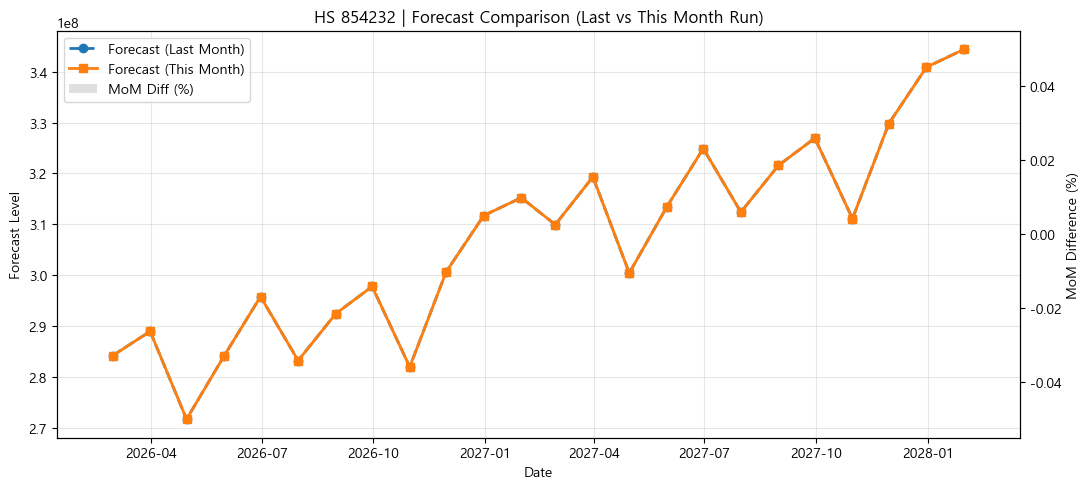

hs_code_6d,Forecast (Last Month),Forecast (This Month),MoM Diff (%)
date,,,
2026-02-28,2.841551e+08,2.841551e+08,0.0
2026-03-31,2.889304e+08,2.889304e+08,0.0
2026-04-30,2.716483e+08,2.716483e+08,0.0
2026-05-31,2.841242e+08,2.841242e+08,0.0
2026-06-30,2.957683e+08,2.957683e+08,0.0
2026-07-31,2.831944e+08,2.831944e+08,0.0
2026-08-31,2.924045e+08,2.924045e+08,0.0
2026-09-30,2.977565e+08,2.977565e+08,0.0
2026-10-31,2.819329e+08,2.819329e+08,0.0


In [7]:

last_win = (last_month_fc_pivot.loc[FORECAST_START:FORECAST_END, [TARGET_HSCODE]]
            .rename(columns={TARGET_HSCODE: 'Forecast (Last Month)'}).sort_index()
            if TARGET_HSCODE in last_month_fc_pivot.columns else pd.DataFrame())
this_win = (this_month_fc_pivot.loc[FORECAST_START:FORECAST_END, [TARGET_HSCODE]]
            .rename(columns={TARGET_HSCODE: 'Forecast (This Month)'}).sort_index()
            if TARGET_HSCODE in this_month_fc_pivot.columns else pd.DataFrame())

df_plot = last_win.join(this_win, how='outer')
df_plot['MoM Diff (%)'] = (
    (df_plot['Forecast (This Month)'] - df_plot['Forecast (Last Month)'])
    / df_plot['Forecast (Last Month)']
) * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(df_plot.index, df_plot['Forecast (Last Month)'],
         linestyle='--', marker='o', linewidth=2, label='Forecast (Last Month)')
ax1.plot(df_plot.index, df_plot['Forecast (This Month)'],
         linestyle='-', marker='s', linewidth=2, label='Forecast (This Month)')
ax1.set_xlabel('Date'); ax1.set_ylabel('Forecast Level'); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(df_plot.index, df_plot['MoM Diff (%)'], color='gray', alpha=0.25, width=20,
        label='MoM Diff (%)')
ax2.set_ylabel('MoM Difference (%)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title(f'HS {TARGET_HSCODE} | Forecast Comparison (Last vs This Month Run)')
plt.tight_layout(); plt.show()

df_plot


## ⑥ YoY 수입증가율의 "변화(가속/둔화)" 분석
같은 미래 대상월/대상분기에 대해, 전달 run과 이번달 run의 YoY 증가율을 비교합니다.


[비교 대상 run] 전달: 2026-06-14   vs   이번달: 2026-07-24   |  HS: 854232

[표1] 월별 YoY 수입증가율 변화 (HS 854232)


,old_yoy(%),recent_yoy(%),diff(%p)
date,,,
2026-02-28,41.13,41.13,0.0
2026-03-31,48.19,48.19,0.0
2026-04-30,84.72,84.72,0.0
2026-05-31,95.15,95.15,0.0
2026-06-30,30.45,30.45,0.0
2026-07-31,91.45,91.45,0.0
2026-08-31,71.75,71.75,0.0
2026-09-30,92.66,92.66,0.0
2026-10-31,40.57,40.57,0.0


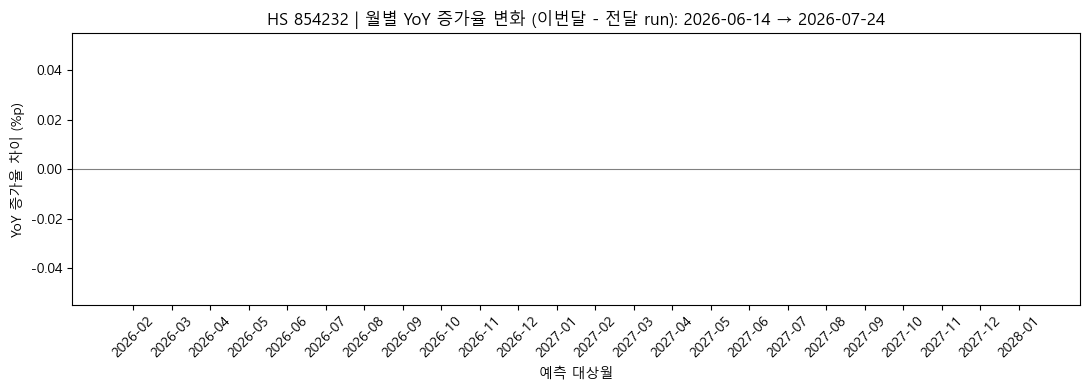


[표2] 분기별 YoY 수입증가율 변화 (HS 854232)


,old_quarterly_yoy(%),recent_quarterly_yoy(%),diff(%p)
date,,,
2026-03-31,42.03,42.03,0.0
2026-06-30,63.95,63.95,0.0
2026-09-30,84.75,84.75,0.0
2026-12-31,24.96,24.96,0.0
2027-03-31,11.19,11.19,0.0
2027-06-30,10.24,10.24,0.0
2027-09-30,10.03,10.03,0.0
2027-12-31,9.79,9.79,0.0
2028-03-31,-63.53,-63.53,0.0


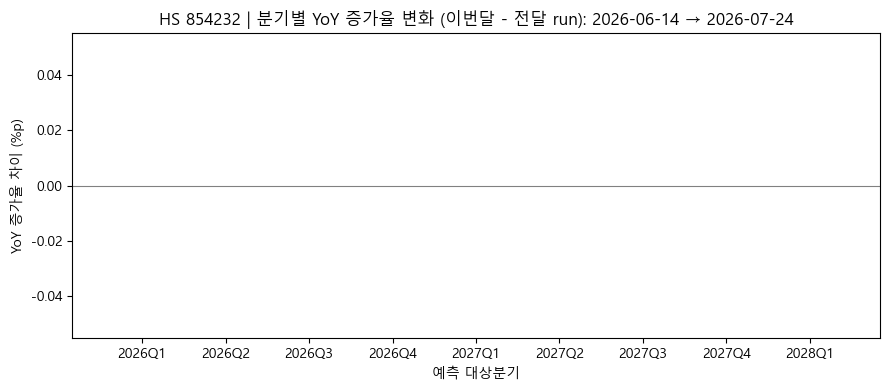


월별 평균 변화: +0.00%p → 변화 없음
분기별 평균 변화: +0.00%p → 변화 없음


In [8]:

old_v, recent_v = LAST_MONTH_VINTAGE, THIS_MONTH_VINTAGE
hs = TARGET_HSCODE
print(f"[비교 대상 run] 전달: {old_v}   vs   이번달: {recent_v}   |  HS: {hs}")

old_combined    = last_month_series
recent_combined = this_month_series
old_fc_dates    = last_month_fc_pivot.index if TARGET_HSCODE in last_month_fc_pivot.columns else pd.DatetimeIndex([])
recent_fc_dates = this_month_fc_pivot.index if TARGET_HSCODE in this_month_fc_pivot.columns else pd.DatetimeIndex([])

if len(old_fc_dates) == 0 or len(recent_fc_dates) == 0:
    raise ValueError(f"HS {hs}에 대해 LAST_MONTH_VINTAGE 또는 THIS_MONTH_VINTAGE 시점의 예측 데이터가 없습니다.")

# [표1] 월별 YoY 수입증가율 변화
old_yoy    = old_combined.pct_change(12) * 100
recent_yoy = recent_combined.pct_change(12) * 100

common_months = old_fc_dates.intersection(recent_fc_dates).sort_values()

table1 = pd.DataFrame({
    "date": common_months,
    "old_yoy(%)": old_yoy.reindex(common_months).values,
    "recent_yoy(%)": recent_yoy.reindex(common_months).values,
})
table1["diff(%p)"] = table1["recent_yoy(%)"] - table1["old_yoy(%)"]
table1 = table1.set_index("date")

print(f"\n[표1] 월별 YoY 수입증가율 변화 (HS {hs})")
display(table1.round(2))

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in table1["diff(%p)"]]
ax.bar(table1.index.strftime("%Y-%m"), table1["diff(%p)"], color=colors)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title(f"HS {hs} | 월별 YoY 증가율 변화 (이번달 - 전달 run): {old_v} → {recent_v}")
ax.set_xlabel("예측 대상월")
ax.set_ylabel("YoY 증가율 차이 (%p)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# [표2] 분기별(합산 기준) YoY 수입증가율 변화
def quarterly_yoy_for_vintage(monthly_combined, fc_dates):
    q_sum = monthly_combined.resample("QE").sum()
    q_yoy = q_sum.pct_change(4) * 100
    fc_quarter_ends = pd.to_datetime(fc_dates).to_period("Q").end_time.normalize().unique()
    return q_yoy, pd.DatetimeIndex(fc_quarter_ends)

old_qyoy, old_fc_q       = quarterly_yoy_for_vintage(old_combined, old_fc_dates)
recent_qyoy, recent_fc_q = quarterly_yoy_for_vintage(recent_combined, recent_fc_dates)

common_quarters = old_fc_q.intersection(recent_fc_q).sort_values()

table2 = pd.DataFrame({
    "date": common_quarters,
    "old_quarterly_yoy(%)": old_qyoy.reindex(common_quarters).values,
    "recent_quarterly_yoy(%)": recent_qyoy.reindex(common_quarters).values,
})
table2["diff(%p)"] = table2["recent_quarterly_yoy(%)"] - table2["old_quarterly_yoy(%)"]
table2 = table2.set_index("date")

print(f"\n[표2] 분기별 YoY 수입증가율 변화 (HS {hs})")
display(table2.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
colors2 = ["#2ca02c" if v >= 0 else "#d62728" for v in table2["diff(%p)"]]
ax.bar(table2.index.to_period("Q").astype(str), table2["diff(%p)"], color=colors2)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title(f"HS {hs} | 분기별 YoY 증가율 변화 (이번달 - 전달 run): {old_v} → {recent_v}")
ax.set_xlabel("예측 대상분기")
ax.set_ylabel("YoY 증가율 차이 (%p)")
plt.tight_layout()
plt.show()

accel_month = table1["diff(%p)"].mean()
accel_q     = table2["diff(%p)"].mean()
dir_m = "가속(상향 수정)" if accel_month > 0 else ("둔화(하향 수정)" if accel_month < 0 else "변화 없음")
dir_q = "가속(상향 수정)" if accel_q > 0 else ("둔화(하향 수정)" if accel_q < 0 else "변화 없음")
print(f"\n월별 평균 변화: {accel_month:+.2f}%p → {dir_m}")
print(f"분기별 평균 변화: {accel_q:+.2f}%p → {dir_q}")


## ⑦ 최근 N년 실적 + 향후 예측 결합 → YoY 성장률의 "가속도"(월별 차분) 전체 흐름



[최근 5년 + 예측] YoY 성장률 및 가속도 (HS 854232)


,value,yoy(%),yoy_accel(%p),구간
date,,,,
2025-02-28,2.013376e+08,48.17,-1.61,실적
2025-03-31,1.949728e+08,36.17,-12.00,실적
2025-04-30,1.470584e+08,2.07,-34.10,실적
2025-05-31,1.455924e+08,-1.41,-3.48,실적
2025-06-30,2.267264e+08,71.49,72.90,실적
2025-07-31,1.479228e+08,8.29,-63.20,실적
2025-08-31,1.702546e+08,3.87,-4.42,실적
2025-09-30,1.545523e+08,-25.38,-29.25,실적
2025-10-31,2.005692e+08,69.07,94.46,실적


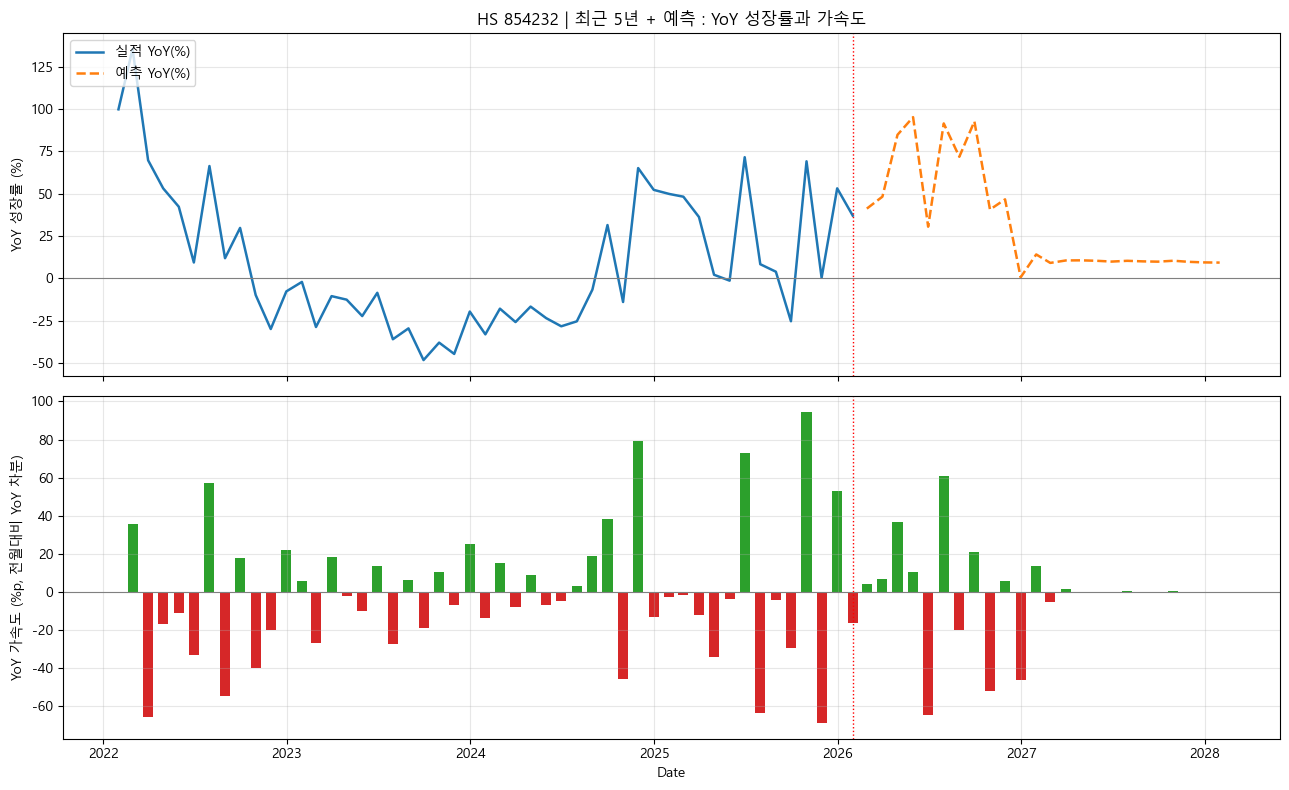


[참고] YoY 상위 10% 급등/급락 구간 (|YoY| >= 71.1%) → 기저효과 점검 후보


,value,base_12m_ago,yoy(%),yoy_accel(%p),구간
date,,,,,
2022-01-31,2.058405e+08,103043387.0,99.76,NaN,실적
2022-02-28,2.325924e+08,98782155.0,135.46,35.70,실적
2025-06-30,2.267264e+08,132208755.0,71.49,72.90,실적
2026-04-30,2.716483e+08,147058422.0,84.72,36.53,예측
2026-05-31,2.841242e+08,145592354.0,95.15,10.43,예측
2026-07-31,2.831944e+08,147922840.0,91.45,61.00,예측
2026-08-31,2.924045e+08,170254599.0,71.75,-19.70,예측
2026-09-30,2.977565e+08,154552348.0,92.66,20.91,예측


In [9]:

HIST_YEARS_FOR_ACCEL = 5

accel_base_date = LAST_ACTUAL_DATE - pd.DateOffset(years=HIST_YEARS_FOR_ACCEL)
accel_series = recent_combined.loc[recent_combined.index >= accel_base_date].sort_index()

accel_yoy = accel_series.pct_change(12) * 100
accel_yoy_diff = accel_yoy.diff(1)

accel_df = pd.DataFrame({
    "value": accel_series,
    "yoy(%)": accel_yoy,
    "yoy_accel(%p)": accel_yoy_diff,
})
accel_df["구간"] = ["실적" if d <= LAST_ACTUAL_DATE else "예측" for d in accel_df.index]

print(f"\n[최근 {HIST_YEARS_FOR_ACCEL}년 + 예측] YoY 성장률 및 가속도 (HS {hs})")
display(accel_df.round(2).tail(36))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

is_actual = accel_df.index <= LAST_ACTUAL_DATE
ax1.plot(accel_df.index[is_actual], accel_df["yoy(%)"][is_actual],
          color="#1f77b4", linewidth=1.8, label="실적 YoY(%)")
ax1.plot(accel_df.index[~is_actual], accel_df["yoy(%)"][~is_actual],
          color="#ff7f0e", linewidth=1.8, linestyle="--", label="예측 YoY(%)")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.axvline(LAST_ACTUAL_DATE, color="red", linestyle=":", linewidth=1)
ax1.set_ylabel("YoY 성장률 (%)")
ax1.set_title(f"HS {hs} | 최근 {HIST_YEARS_FOR_ACCEL}년 + 예측 : YoY 성장률과 가속도")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

colors3 = ["#2ca02c" if v >= 0 else "#d62728" for v in accel_df["yoy_accel(%p)"]]
ax2.bar(accel_df.index, accel_df["yoy_accel(%p)"], color=colors3, width=20)
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.axvline(LAST_ACTUAL_DATE, color="red", linestyle=":", linewidth=1)
ax2.set_ylabel("YoY 가속도 (%p, 전월대비 YoY 차분)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

threshold = accel_df["yoy(%)"].abs().quantile(0.90)
flagged = accel_df[accel_df["yoy(%)"].abs() >= threshold].copy()
flagged["base_12m_ago"] = accel_series.shift(12).reindex(flagged.index)

if len(flagged) > 0:
    print(f"\n[참고] YoY 상위 10% 급등/급락 구간 (|YoY| >= {threshold:.1f}%) → 기저효과 점검 후보")
    display(flagged[["value", "base_12m_ago", "yoy(%)", "yoy_accel(%p)", "구간"]].round(2))
else:
    print("\n[참고] 뚜렷한 급등/급락 구간이 발견되지 않았습니다.")


## ⑧ 실적(실선) + 예측(점선) 연속 차트

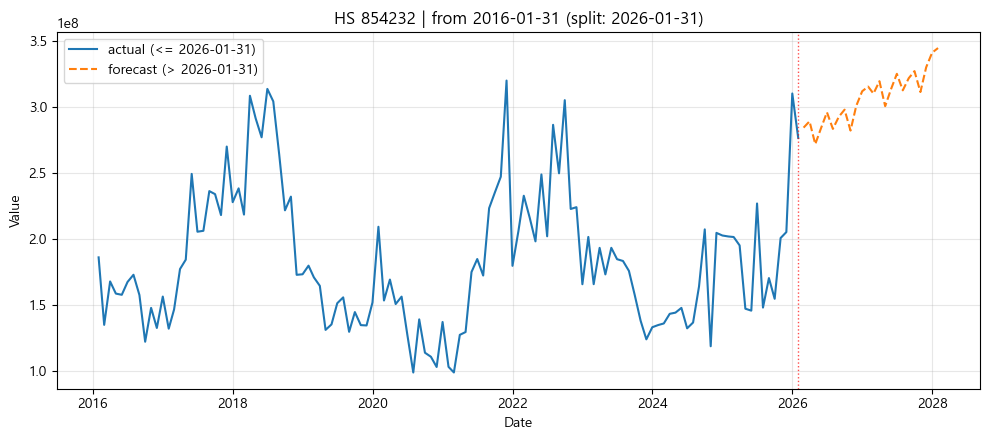

In [10]:

def plot_series_split(series: pd.Series, split_date, n_months: int, title: str,
                       save_path: str | None = None, show: bool = True):
    c = pd.to_datetime(split_date)
    start = c - pd.DateOffset(months=n_months)
    sub = series.loc[series.index >= start].sort_index()
    left = sub.loc[sub.index <= c]
    right = sub.loc[sub.index > c]

    plt.figure(figsize=(10, 4.5))
    plt.plot(left.index, left.values, label=f"actual (<= {c.date()})", linewidth=1.5)
    if not right.empty:
        plt.plot(right.index, right.values, linestyle="--",
                  label=f"forecast (> {c.date()})", linewidth=1.5)
    plt.axvline(c, color='red', linestyle=":", linewidth=1, alpha=0.7)
    plt.title(title)
    plt.xlabel("Date"); plt.ylabel("Value")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


plot_series_split(
    this_month_series, SPLIT_DATE, HIST_MONTHS,
    title=f"HS {TARGET_HSCODE} | from {(pd.to_datetime(SPLIT_DATE) - pd.DateOffset(months=HIST_MONTHS)).date()} (split: {pd.to_datetime(SPLIT_DATE).date()})",
)


## ⑨ HS 코드별 데이터 저장

In [11]:

import os
from pathlib import Path
from datetime import datetime

EXPORT_DIR = Path(os.environ.get("EXPORT_DIR_OVERRIDE", str(Path.home() / "reports" / "us_import_data")))
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f"[저장 경로] {EXPORT_DIR}")

today_str = datetime.today().strftime('%Y%m%d')


def save_hscode_data(df, hscode, n_periods=28, save_excel=True, save_csv=True):
    if hscode not in df.columns:
        print(f"[SKIP] {hscode} : 데이터프레임에 존재하지 않는 HS 코드")
        return

    data = df[[hscode]].tail(n_periods).copy()
    data.index.name = 'date'

    base_name = f'us_import_hscode_{hscode}_{today_str}'

    if save_excel:
        xlsx_path = EXPORT_DIR / (base_name + '.xlsx')
        data.to_excel(xlsx_path)
        print(f"[저장 완료] {xlsx_path}")

    if save_csv:
        csv_path = EXPORT_DIR / (base_name + '.csv')
        data.to_csv(csv_path, encoding='utf-8-sig')
        print(f"[저장 완료] {csv_path}")


save_hscode_data(trade_total_df, TARGET_HSCODE, n_periods=60)

# hscode_list = ['854232', '870380', '271012']
# for hs in hscode_list:
#     save_hscode_data(trade_total_df, hs, n_periods=28)


[저장 경로] C:\Users\82108\reports\us_import_data
[저장 완료] C:\Users\82108\reports\us_import_data\us_import_hscode_854232_20260724.xlsx
[저장 완료] C:\Users\82108\reports\us_import_data\us_import_hscode_854232_20260724.csv


## ⑩ 대상 HS 코드 전체 시계열(실적+예측) 조회

In [12]:

trade_total_df[[TARGET_HSCODE]].tail(36)


hs_code,854232
date,
2025-02-28,2.013376e+08
2025-03-31,1.949728e+08
2025-04-30,1.470584e+08
2025-05-31,1.455924e+08
2025-06-30,2.267264e+08
2025-07-31,1.479228e+08
2025-08-31,1.702546e+08
2025-09-30,1.545523e+08
2025-10-31,2.005692e+08


## ⑪ 성장률 7종 종합 long-format 테이블 (전체 HS 코드)

과거12개월 / 향후12개월 / 당해(YTD) 예상 / 올해 전체 예상 / 작년 / YoY / MoM 을
전체 HS 코드에 대해 한 번에 계산해서 하나의 long-format DataFrame으로 만듭니다.
(수출 버전 `build_export_growth_long` 과 동일한 스키마)


In [13]:

save_path_long = str(EXPORT_DIR)  # 위 ⑨에서 만든 저장 경로 재사용

import_long_df = build_import_growth_long(
    engine=engine,
    reference_date=None,      # None -> HS코드별 최신 실측월을 기준월로 자동 사용
    window_months=12,
    save_path=save_path_long,
)

import_long_df.head(20)


[최신 vintage] 2026-07-24 기준 70,625 행 / HS 476개 로드

[vintage: 2026-07-24] 총 25,228 행 생성 (HS 476개 x 지표 7종) / 유효 growth_rate 24,330건
                    rows  valid
metric_type                    
full_year_growth     476    473
future_12m_growth    476    440
last_year_growth     476    476
mom_growth         11424  10992
past_12m_growth      476    476
yoy_growth         11424  10997
ytd_growth           476    476

[저장] C:\Users\82108\reports\us_import_data\import_growth_long_20260724.csv (25,228 rows)


,hs_code,reference_date,metric_type,metric_date,period_label,base_value,compare_value,growth_rate,flag
0,100630,2026-01-31,past_12m_growth,2026-01-31,2025-02~2026-01 vs 2024-02~2025-01,1.406995e+09,1.430588e+09,1.676819,None
1,100630,2026-01-31,future_12m_growth,2027-01-31,2026-02~2027-01 vs 2025-02~2026-01,1.430588e+09,1.540440e+09,7.678840,None
2,100630,2026-01-31,ytd_growth,2026-01-31,2026-01~2026-01 vs 2025-01~2025-01,1.426788e+08,1.419971e+08,-0.477770,None
3,100630,2026-01-31,full_year_growth,2026-12-31,"2026(실측+예측, 12개월) vs 2025(실측)",1.431270e+09,1.539553e+09,7.565550,None
4,100630,2026-01-31,last_year_growth,2025-12-31,2025 vs 2024,1.369189e+09,1.431270e+09,4.534133,None
5,100630,2026-01-31,mom_growth,2025-02-28,2025-02 vs 2025-01,1.426788e+08,1.257074e+08,-11.894842,None
6,100630,2026-01-31,yoy_growth,2025-02-28,2025-02 vs 2024-02,8.416378e+07,1.257074e+08,49.360446,None
7,100630,2026-01-31,mom_growth,2025-03-31,2025-03 vs 2025-02,1.257074e+08,1.432481e+08,13.953607,None
8,100630,2026-01-31,yoy_growth,2025-03-31,2025-03 vs 2024-03,1.320138e+08,1.432481e+08,8.509911,None
9,100630,2026-01-31,mom_growth,2025-04-30,2025-04 vs 2025-03,1.432481e+08,1.286680e+08,-10.178242,None
